# 영어 학습자 에세이 어휘 수준 예측 (ELL Vocabulary Score Prediction)

영어 학습자(English Language Learner)가 작성한 에세이에서 **언어학적 지표를 추출하여 어휘 수준 점수(vocabulary)를 예측하는 회귀 모델**을 구축한 프로젝트입니다.

> 삼성중공업 스마트조선소 AI 전문가 양성과정 (KDT) — 미니프로젝트 실습평가
> 기간: 2026.08.12 ~ 2026.08.20 | 개인 프로젝트

---

## 1. 프로젝트 배경

### 1.1 항목별 자동 채점은 이미 산업에서 운영 중인 기능이다

에세이 자동 채점에서 **총점 하나만 산출하는 것과 항목별 점수를 산출하는 것은 용도가 다른 제품**이며,
후자는 이미 상용 시험 서비스에 탑재되어 있습니다.

| 서비스 | 항목별 자동 채점 현황 |
|---|---|
| **Pearson PTE Academic** | Overall·4개 communicative skills 외에 enabling skills 6종(grammar, oral fluency, pronunciation, spelling, **vocabulary**, written discourse)을 별도 산출. Pearson의 AI 채점 엔진이 담당 |
| **ETS Criterion / e-rater** | 전체 품질 점수와 함께 word choice 등 trait 점수를 제공. 2013년 이후 제출물에는 organization/development, **vocabulary**, conventions 3개 trait 등급을 기록 |

국내 사례로는 KICE Essay Scorer(KES) 2.0이 대규모 영어 쓰기 평가에 적용되어,
인간 채점과 비교했을 때 교차신뢰도 및 시험 점수 신뢰도에서 유의미한 차이가 없었고
**채점자 엄격도(rater severity)의 영향은 인간 채점보다 오히려 작았다**고 보고되었습니다.

특히 PTE의 enabling skills 점수는 **응시자 본인만 열람할 수 있고 지원 대학·기관에는 전달되지 않습니다.**
이는 제품 설계 단계에서 두 지표의 용도가 명시적으로 분리되어 있음을 보여줍니다.

- **Overall** → 판정용 (합격/불합격, 입학 자격 심사)
- **항목별 점수** → 진단·피드백용 (학습자 본인의 개선 방향 파악)

### 1.2 왜 Overall이 아니라 항목별 점수를 예측하는가

평가 연구에서 분석적(다항목) 채점이 사용되는 근거는 **응시자의 구체적 강점과 약점을 포착하여 교수·학습을 안내**하는 데 있습니다.
이를 서비스 관점으로 옮기면 차이가 분명해집니다.

| 출력 | 학습자가 취할 수 있는 다음 행동 |
|---|---|
| "당신의 점수는 3.0입니다" | 없음 — 결과 통보에 그침 |
| "어휘 2.5 / 문법 3.5입니다" | 어휘 학습으로 자원 배분 결정 가능 |

항목별 점수는 단순한 표시 문구가 아니라 **학습 콘텐츠 추천 엔진의 입력 신호**로 기능합니다.
Overall만으로는 다음 콘텐츠를 선택할 수 없지만, 항목별 점수가 있으면 취약 항목 모듈로 라우팅할 수 있습니다.
교사 입장에서도 학급 전체에서 어휘 취약군만 선별하는 것이 가능해집니다.

실제로 137만 건의 Criterion 제출물을 분석한 ETS 연구는 항목별 피드백을 받은 학생들의
문법·어법·철자가 지속적으로 향상되었음을 보고했습니다. 항목별 진단이 실제 학습 행동을 바꾼다는 실증 근거입니다.

### 1.3 정량적 효과 추정

#### 출처 신뢰도 등급 분류

자동 채점의 비용 절감 수치는 출처에 따라 신뢰도 편차가 매우 큽니다.
본 절은 수집한 자료를 다음 3등급으로 분류하고, **A·B등급만 근거로 채택**합니다.

| 등급 | 정의 | 채택 |
|---|---|---|
| **A** | 학술 논문·메타분석·시험기관(ETS, KICE)의 1차 보고 | ✅ |
| **B** | 방법론이 공개된 업계 조사 (표본·산정식 확인 가능) | ✅ 범위 표기 |
| **C** | 벤더 마케팅 자료·리드 확보용 ROI 계산기 | ❌ 미채택 |

**C등급으로 분류하여 제외한 수치 (수집은 했으나 인용하지 않음)**

| 수치 | 출처 | 제외 사유 |
|---|---|---|
| 연간 ROI 300~500% | AI 채점 벤더 가격 페이지 | 자사 제품 판촉 자료, 산정식 비공개 |
| 교사 1인당 연 $40,000+ 절감 | 벤더 ROI 계산기 | 리드 확보용 도구, 입력 가정 임의 |
| 채점 시간 60~80% 절감 | 벤더 ROI 계산기 | 표본·측정 방법 미공개 |
| K-12 출판사 70~80% 절감 | 벤더 블로그 | 사례 수·조건 미공개 |
| AES 시장 규모 | 상용 마켓리포트 4종 | 동일 시장에 대해 **약 80배 편차** (1.23억~103억 달러), 산정 방식 비공개 |

> 이 수치들이 틀렸다고 단정하는 것이 아니라, **검증할 수 없어 근거로 쓸 수 없다**는 판단입니다.
> 발표 시 출처를 질문받았을 때 방어할 수 없는 수치는 프로젝트 전체의 신뢰도를 함께 떨어뜨립니다.

#### A등급 — 채택 근거

| 지표 | 값 | 출처 |
|---|---|---|
| 자동 채점–인간 채점 완전일치도 | **52%** (근접일치 93%) | 메타분석 (2014) |
| 인간 채점자 간 완전일치도 | **54%** (근접일치 94%) | 동일 메타분석 |
| e-rater 도입 시 2차 인간 채점 필요 사례 감소 | **41~47%** | ETS (2016) |
| 국내 대규모 쓰기평가 자동채점(KES 2.0) 신뢰도 | 인간 채점 대비 **유의미한 차이 없음** | 임황규 (2014) |

첫 두 행이 핵심입니다. **자동 채점의 인간 일치도(52%)는 인간 채점자끼리의 일치도(54%)와 사실상 동일합니다.**
즉 자동화의 근거는 "기계가 사람보다 정확해서"가 아니라 **"사람도 이 정도밖에 일치하지 않으므로, 동일 비용에서 기계가 대체 가능하다"**입니다.

#### B등급 — 원단위 비용 (ASAP Pricing Study, 2014)

150만~300만 명 규모 시험의 주관식 채점 비용을 인간 채점과 기계 채점으로 비교한 조사입니다.

| 구분 | 학생 1인당 단가 | 총액 |
|---|---:|---:|
| 인간 채점 | $1.51 ~ $2.08 | $340만 ~ $470만 |
| 기계 채점 | $0.41 ~ $0.86 | $92만 ~ $190만 |
| **절감** | — | **$250만 ~ $280만 (약 55~60%)** |

#### 본 데이터셋 규모에 적용

| 항목 | 값 | 근거 |
|---|---:|---|
| 대상 에세이 | **3,911편** | **[실측]** 본 데이터셋 |
| 에세이당 채점자 | **2인** | **[실측]** ELLIPSE 채점 프로토콜 |
| 총 채점 건수 | **7,822건** | **[실측]** 3,911 × 2 |

| 시나리오 | 채점 비용 | 산출 |
|---|---:|---|
| 인간 채점 단독 | **$5,906 ~ $8,135** | 3,911 × $1.51~2.08 |
| 기계 채점 도입 | **$1,604 ~ $3,364** | 3,911 × $0.41~0.86 |
| **절감액** | **$4,302 ~ $4,771** | 약 55~60% |

ETS의 2차 채점 감소율(41~47%)을 적용할 경우, 총 채점 건수는 7,822건에서
**5,984~6,219건으로 감소**합니다 (전체 채점 공수 기준 약 20~24% 감소).

#### 서비스 규모 확장 시나리오 — 연 10만 편 **[가정]**

| 구분 | 연간 비용 |
|---|---:|
| 인간 채점 단독 | $151,000 ~ $208,000 |
| 기계 채점 도입 | $41,000 ~ $86,000 |
| **연간 절감** | **약 $100,000 내외 (55~60%)** |

연 10만 편은 중형 어학시험·학습 서비스의 처리량을 상정한 시나리오이며 실제 사업 계획이 아닙니다.
단가는 위 B등급 조사값을 그대로 적용했습니다.

#### 정량화하지 않은 효과

| 효과 | 정량화 | 사유 |
|---|---|---|
| 채점 인건비 절감 | **가능** | 위 표 |
| 결과 회신 주기 단축 | **부분 가능** | 주 단위 → 일 단위 단축이 보고되나 조건별 편차 큼 |
| 채점 일관성 확보 | **가능** | 채점자 엄격도 영향 감소가 KES 2.0에서 측정됨 |
| 개인화 추천을 통한 리텐션·전환 향상 | **불가** | 서비스 로그 없이 전환율 가정은 검증 불가. 정성적 논거로만 다룸 |

마지막 항목을 수치화하지 않은 것은 의도적입니다.
근거 없는 전환율을 곱해 만든 매출 추정치는 위 표의 신뢰도까지 함께 훼손합니다.

### 1.4 해석 가능한 모델을 택한 이유

자동 에세이 채점(Automated Essay Scoring)에서 딥러닝 기반 접근은 높은 성능을 내지만,
**어떤 언어적 특성 때문에 그 점수가 나왔는지 설명하지 못한다**는 한계가 있습니다.
§1.2에서 정리했듯 항목별 점수의 존재 이유가 '진단'이라면, 설명할 수 없는 진단은 그 목적을 달성하지 못합니다.

이 프로젝트는 블랙박스 모델 대신 **해석 가능한 언어학적 지표를 직접 설계하고**,
그 지표들이 실제 채점자의 어휘 평가를 얼마나 설명하는지 회귀 분석으로 검증합니다.

영어영문학 전공 배경에서 나온 어휘론·코퍼스 언어학 지식을 피처 설계에 직접 반영한 것이 이 프로젝트의 핵심입니다.

## 2. 문제 정의

| 항목 | 내용 |
|---|---|
| 문제 유형 | 지도학습 · **회귀(Regression)** |
| Target | `Vocabulary` (어휘 수준 점수, 1.0 ~ 5.0, 0.5 단위) |
| Input | 에세이 원문에서 파생한 언어학적 지표 + 글의 속성 메타데이터 |
| 평가 지표 | MAE, MSE, RMSE, R² |

### 2.1 왜 6개 항목 중 vocabulary인가

ELLIPSE는 cohesion, syntax, vocabulary, phraseology, grammar, conventions 6개 항목 점수를 제공합니다.
그중 vocabulary를 택한 이유는 다음과 같습니다.

**① 6개 항목 중 개입 가능성(intervenability)이 가장 높다**

진단의 가치는 처방 가능성에 비례합니다. 어휘는 단어장·콜로케이션 학습·코퍼스 기반 연습 등
**단기간의 명시적 학습으로 개선 가능한 항목**이며 처방이 구체적입니다.
반면 syntax나 cohesion은 개선에 훨씬 긴 시간이 필요하고 처방도 모호합니다.

**② 채점자 간 일치도가 가장 낮은 항목이다 — 이것이 오히려 자동화의 명분이다**

ELLIPSE 원논문에 따르면 vocabulary의 채점자 간 일치도(Cohen's Kappa)는 **.518로 7개 지표 중 최하위**이며,
저자들 스스로도 기준선(.60)에 미달한다고 평가했습니다.

> 사람 채점자 둘의 일치도가 가장 낮다는 것은, 이 항목이 채점자에 따라 결과가 가장 크게 흔들린다는 뜻이다.
> 모델은 사람보다 정확하지는 못해도 **항상 동일한 기준을 적용한다.**
> **일관성이 가장 부족한 항목이 자동화 가치가 가장 큰 항목이다.**

**③ 상용 시스템에서 어휘 특징의 기여도가 이미 입증되어 있다**

ETS e-rater V.2에서 주제 특화 어휘 관련 특징 2개가 **전체 채점 가중치의 평균 약 15%**를 차지합니다.
어휘 지표가 총점 예측에 실질적으로 기여한다는 것이 상용 엔진의 가중치 구조로 확인된 셈이며,
본 프로젝트가 설계할 어휘 피처(TTR, MTLD, 저빈도어 비율 등)와 같은 계열의 지표입니다.

**④ 구현 관점의 실무적 이유**

- 어휘 다양성(TTR, MTLD), 저빈도어 비율, 평균 어휘 길이 등 **파서 없이 텍스트에서 직접 산출 가능한 지표**가 어휘 능력과 직결됩니다.
- syntax는 종속절 비율·구문 트리 깊이 계산을 위해 파싱 단계가 필요해 5일 일정에 부담이 큽니다.
- 파이프라인이 완성되면 **타겟 변수만 교체하여 다른 항목으로 확장 가능**하도록 설계했습니다.

### 2.2 성능 기대치와 한계 — 비환원 오차(irreducible error)

#### 라벨 자체가 모델 성능의 상한을 결정한다

2.1 ②의 채점자 일치도 .518은 성능 상한을 규정하는 요인이기도 합니다.
정답 라벨이 채점자에 따라 흔들린다면 그 변동분은 어떤 모델로도 설명할 수 없습니다.
이는 ELLIPSE만의 문제가 아니라 에세이 채점 전반의 특성으로, 메타분석에서도
**인간 채점자 간 완전일치도는 54%**에 그칩니다.

#### 선행 연구가 보고한 성능 수준

| 연구 | 접근 | 성능 |
|---|---|---|
| 다차원 채점 모델 | 6개 차원 동시 예측 | **Vocabulary 차원 Pearson r = 0.599** (Spearman 0.605) |
| Stanford CS229 (2012) | 얕은 언어 피처 + 선형회귀 | QWK 0.73 (총점) |
| Stanford CS229 (2013) | SVM 회귀 | κ = 0.78 (총점) |
| TransGAT (2025) | 그래프 신경망 다차원 | 평균 QWK 0.854 |

첫 행이 본 프로젝트의 직접적인 비교 기준입니다.
**Vocabulary 차원의 Pearson r = 0.599는 결정계수로 환산 시 약 0.36**에 해당합니다.
딥러닝 기반 다차원 모델도 어휘 차원에서는 이 수준이라는 뜻이며,
이는 §1.3에서 확인한 라벨 신뢰도의 구조적 한계와 일치합니다.

> **확인 필요:** 해당 수치의 학습 데이터가 ELLIPSE인지 여부는 원문 확인이 필요합니다.
> 동일 데이터라면 직접 비교 가능한 벤치마크, 아니라면 참고 수준으로만 사용합니다.

#### 본 프로젝트의 목표 성능

| 구분 | 내용 |
|---|---|
| 기대 성능 | **R² 0.30 ~ 0.45**, MAE 0.35 ~ 0.45 |
| 근거 | 선행 다차원 모델의 Vocabulary 차원 R² 환산값(약 0.36)과 동일 구간 |
| 해석 | 낮은 R²는 모델 실패가 아니라 **문제의 구조적 특성** |
| 검증 방법 | 신뢰도가 높은 `Overall`을 대조군으로 함께 모델링하여, 채점자 일치도 차이가 모델 성능 차이로 나타나는지 확인 |

목표 성능을 결과가 나온 뒤 사후 정당화하는 것이 아니라
**선행 연구 수치를 근거로 사전에 선언**하고, 달성 여부를 검증하는 방식으로 진행합니다.

#### 예상되는 반론과 대응

**"신뢰도가 낮은 라벨을 굳이 예측하는 것이 타당한가"**
정당한 반론입니다. ETS 연구에서도 trait 점수가 총점 대비 추가적 가치를 갖는지를
별도 검증한 뒤에야 사용을 뒷받침했습니다.
본 프로젝트는 위 표의 `Overall` 대조군 실험으로 이 반론 자체를 결과의 일부로 편입합니다.

**"인간 채점보다 부정확한 모델을 쓸 이유가 있는가"**
자동 채점–인간 일치도(52%)는 인간 채점자 간 일치도(54%)와 사실상 동일합니다(§1.3).
또한 고부담 시험에서는 완전 대체가 아니라 **2차 채점자 대체 또는 하이브리드 운영**이 표준이며,
ETS는 이 방식으로 2차 인간 채점 필요 사례를 41~47% 줄였습니다.

## 3. 데이터셋

**ELLIPSE Corpus** (English Language Learner Insight, Proficiency and Skills Evaluation)

- 출처: https://github.com/scrosseye/ELLIPSE-Corpus (실제 내려받은 파일은 Kaggle 배포본 — `text_id_kaggle` 컬럼 존재)
- 규모: 실제 사용 파일 기준 **3,911편** (미국 8~12학년 영어 학습자 작성)
- 수집 맥락: 미국 주(state) 단위 표준화 시험에서 실제 작성된 에세이
- 프롬프트: 배경지식을 요구하지 않는 독립형 주제. **실제 사용 파일 기준 44종** (원논문 최종 코퍼스는 6,482편·29종으로, 배포 파일과 범위가 다름 → 본 프로젝트는 파일 실측치를 기준으로 함)
- 채점: 훈련된 채점자 2인이 전체 숙련도 점수 및 6개 세부 항목 점수 부여

### 주요 컬럼

| 컬럼 | 설명 |
|---|---|
| `full_text` | 에세이 원문 |
| `overall` | 전체 영어 숙련도 점수 |
| `cohesion` / `syntax` / `vocabulary` / `phraseology` / `grammar` / `conventions` | 세부 항목 점수 |
| `prompt` | 작성 주제 |
| `grade` | 학년 (8~12) |
| 인구통계 정보 | 경제적 배경, 성별, 인종 |

## 4. 파이프라인

```
데이터 수집 → 파생 피처 생성 → 전처리 → EDA → 회귀 모델 구축 → 성능 개선 → Streamlit 대시보드
```

### 4.1 파생 피처 설계

에세이 원문(비정형)을 언어학적 근거를 가진 정형 피처로 변환합니다.

| 범주 | 지표 예시 | 언어학적 근거 |
|---|---|---|
| 어휘 다양성 | TTR, Root TTR, MTLD | 사용 어휘 폭을 직접 반영 |
| 어휘 정교성 | 저빈도어 비율, 평균 어휘 길이, 음절 수 | 고급 어휘 사용 여부 |
| 가독성 | Flesch-Kincaid, Gunning Fog 등 | 텍스트 복잡도 종합 지표 |
| 길이·구조 | 총 단어 수, 문장 수, 평균 문장 길이, 문단 수 | 생산성 및 전개 능력 |
| 표기 | 대소문자·구두점 사용 패턴 | 표기 규범 준수도 |

> **주의:** 총 단어 수는 점수와 강한 상관을 보이지만, 이 변수 하나에 모델이 과도하게 의존하면 "길게 쓰면 점수가 높다"는 모델이 됩니다. 이 문제를 EDA와 정규화 단계에서 다룹니다.

### 4.2 전처리

| 처리 | 내용 |
|---|---|
| 결측치 | 지표 계산 불가 케이스(문장 0개 → 평균 문장 길이 NaN), 메타데이터 결측 |
| 이상치 | 극단적으로 짧은 에세이, 채점자 간 불일치가 큰 건 |
| 중복 | 동일 텍스트 중복 제출 |
| 타입 변환 | 학년(순서형), 점수(연속형) |
| 범주형 인코딩 | `prompt`, `grade` → One-hot vs Target Encoding 비교 |
| Feature Selection | 파생 지표 다수 → 상관계수 및 VIF 기반 다중공선성 제거 |
| Scaling | StandardScaler 적용 |

**Scaling의 중요성 검증:** 파생 지표는 스케일 차이가 큽니다(총 단어 수 약 300 vs TTR 약 0.5). 스케일링을 적용하지 않으면 Ridge/Lasso의 규제가 스케일이 큰 변수에만 편향되어 작동합니다. 이를 적용 전/후로 비교하여 실증합니다.

### 4.3 모델

| 모델 | 목적 | 선행 연구 참고 |
|---|---|---|
| Linear Regression | 베이스라인, 계수 해석 | 얕은 언어 피처만으로 QWK 0.73 달성 사례 (CS229, 2012) |
| Ridge / Lasso | 다중공선성 및 변수 선택 효과 확인 | L1 정규화·전진 특징 선택으로 오차 감소 보고 (CMU, 2012) |
| SVR | 선형 대비 비선형 마진 효과 확인 | LR 대비 MSE 개선 (2.88 → 1.67) 보고 (ijrti, 2022) |
| Random Forest Regressor | 비선형 관계 포착, Feature Importance 도출 | 3개 모델 중 최저 MSE 0.867 보고 (ijrti, 2022) |

선행 연구에서 반복적으로 나타나는 성능 순서는 **Linear < SVR < Random Forest**입니다.
본 프로젝트에서도 동일한 순서가 재현되는지, 재현되지 않는다면 그 원인이 무엇인지를
결과 해석의 한 축으로 다룹니다.

> 딥러닝을 사용하지 않는 이유는 성능이 아니라 **목적**입니다. 회귀 모델은 특징 가중치를
> 해석할 수 있어 "어떤 언어 특징이 점수에 기여하는가"를 설명할 수 있으며(§1.4),
> 데이터·컴퓨팅 요구량이 낮아 중소 규모 평가 환경에서 도입 장벽이 낮습니다.

### 4.4 성능 개선 방향

- 피처 추가/제거 및 상호작용 항 생성
- 이상치 처리 기준 변경에 따른 성능 비교
- 인코딩·스케일링 방식 변경
- 하이퍼파라미터 튜닝 (GridSearchCV)

## 5. 윤리적 고려사항

ELLIPSE는 작성자의 **인종, 성별, 경제적 배경** 정보를 포함합니다.

**이 변수들은 예측 피처에서 의도적으로 제외합니다.**

이들 변수를 투입하면 성능 지표는 일부 개선될 수 있습니다. 그러나 학생의 인종이나 경제적 배경을 근거로 영어 점수를 예측하는 모델은 언어 능력을 측정하는 것이 아니라 **사회적 격차를 학습하여 재생산하는 모델**입니다. 실제 교육 현장에 배포될 경우 특정 집단에 대한 체계적 편향으로 이어집니다.

다만 해당 변수들은 **EDA 단계에서는 분석 대상으로 다룹니다.** 점수 분포가 집단별로 어떻게 다른지 확인하는 것은 데이터가 내포한 편향을 드러내는 작업이며, 모델에서 이를 배제한 판단의 근거가 됩니다.

## 6. 대시보드

Streamlit으로 구현하며 다음 화면으로 구성합니다.

1. **프로젝트 소개** — 배경 및 문제 정의
2. **데이터 정의** — 출처, 변수 설명, 기초 통계
3. **데이터 분석** — EDA 시각화, 지표-점수 상관관계
4. **모델 성능** — 모델별 MAE / RMSE / R² 비교, Feature Importance
5. **예측 시스템** — 영문 에세이를 직접 입력하면 지표를 추출하여 어휘 점수를 예측

## 7. 프로젝트 구조

```
project/
├── data/
│   ├── raw/                  # ELLIPSE 원본
│   └── processed/            # 전처리 완료 데이터
├── notebooks/
│   ├── 01_eda.ipynb
│   ├── 02_feature_engineering.ipynb
│   └── 03_modeling.ipynb
├── src/
│   ├── features.py           # 언어학적 지표 추출
│   ├── preprocess.py         # 전처리 파이프라인
│   └── train.py              # 모델 학습 및 평가
├── models/                   # 학습된 모델 저장
├── app.py                    # Streamlit 대시보드
├── requirements.txt
└── README.md
```

## 8. 실행 방법

```bash
# 가상환경 생성 및 활성화
python -m venv venv
source venv/bin/activate        # Windows: venv\Scripts\activate

# 의존성 설치
pip install -r requirements.txt

# 모델 학습
python src/train.py

# 대시보드 실행
streamlit run app.py
```

**주요 라이브러리:** pandas, numpy, scikit-learn, matplotlib, seaborn, nltk, textstat, streamlit

> 언어 지표 추출은 NLTK와 textstat 조합으로 구성했습니다. spaCy는 설치 및 언어모델 다운로드 과정에서 환경 의존성이 크고, 본 프로젝트의 어휘 관련 지표는 파서 없이도 산출 가능하기 때문입니다.

## 9. 진행 일정

| 일자 | 작업 |
|---|---|
| Day 1 | 데이터 수집, 구조 파악, 가설 설정 |
| Day 2 | 파생 피처 생성, 전처리 |
| Day 3 | EDA 및 시각화 |
| Day 4 | 회귀 모델 구축 및 평가, 성능 개선 |
| Day 5 | Streamlit 대시보드 작성, 결과 정리 |

## 10. 결과

> 진행 중 — 완료 후 업데이트 예정

| 모델 | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | - | - | - |
| Ridge | - | - | - |
| Lasso | - | - | - |
| Random Forest | - | - | - |

## 11. 참고문헌

**데이터셋**

Crossley, S. A., Tian, Y., Baffour, P., Franklin, A., Kim, Y., Morris, W., Benner, B., Picou, A., & Boser, U. (2023). Measuring second language proficiency using the English Language Learner Insight, Proficiency and Skills Evaluation (ELLIPSE) Corpus. *International Journal of Learner Corpus Research, 9*(2), 248-269.

**성능 벤치마크 및 신뢰도 (§2.2 근거) — A등급**

- Agreement rates between automated essay scoring systems and human raters: Meta-analysis (2014). — 자동-인간 완전일치 52% / 근접 93%, 인간-인간 54% / 94%
- 임황규 (2014). 대규모 영어 쓰기 평가를 위한 에세이형 자동채점 시스템 타당화. — KICE Essay Scorer 2.0 신뢰도 검증
- Evaluation of the e-rater Scoring (ETS, 2016) 및 Computer Analysis of Essays (ETS, 2008). — 2차 인간 채점 필요 41~47% 감소
- Automated Essay Scoring (ERIC, 2009). — e-rater V.2 주제 특화 어휘 특징의 가중치 비중 약 15%
- Multi-Task Learning for Multi-Dimensional Essay Scoring (MPhil Thesis). — Vocabulary 차원 Pearson 0.599 / Spearman 0.605
- Automated Essay Grading Using Machine Learning (Stanford CS229, 2012) / Automated Essay Scoring Using Machine Learning (Stanford CS229, 2013). — QWK 0.73, κ 0.78
- Automatic Essay Scoring (CMU, 2012). — L1 정규화 및 특징 선택 효과
- Evaluation of Essay using Machine Learning Techniques (ijrti, 2022). — LR/SVR/RF MSE 비교
- TransGAT: Transformer-Based Graph Neural Networks for Multi-Dimensional AES (2025). — 평균 QWK 0.854

**비용 추정 (§1.3 근거) — B등급**

- ASAP Pricing Study Final (Getting Smart, 2014) / Study Examines Cost Savings Through 'Machine Scoring' of Tests (Market Brief, 2014). — 인간 $1.51~2.08 vs 기계 $0.41~0.86 (학생 1인당)

**수집했으나 미채택 (§1.3 C등급)**

벤더 ROI 계산기 및 마케팅 자료(OpenEduCat, GradeLab, Evelyn Learning, Olive Lab),
상용 AES 마켓리포트 4종(Verified Market Reports, Business Research Insights,
Market Research Intellect, Data Insights Market). 산정 방식 비공개 또는 상호 편차 과다로 제외.

**항목별 자동 채점의 산업 적용 사례 (§1.1, §1.2 근거)**

- Pearson. *PTE Academic Score Guide* — enabling skills(vocabulary 포함) 자동 산출 및 비공개 정책. https://pearson.com.cn/file/PTEA_Score_Guide.pdf
- Educational Testing Service. *Use of e-rater Engine in Criterion Writing Service*. https://www.ets.org/erater/criterion.html
- Attali, Y. (2015). Automated Trait Scores for TOEFL® Writing Tasks. *ETS Research Report Series*. — trait 점수가 총점 대비 갖는 추가적 가치 검증
- Deane, P. et al. (2024). Modeling Writing Traits in a Formative Essay Corpus. *ETS Research Report Series*. — Criterion 제출물 137만 건 분석, 피드백 이후 향상 추이

---

**Author** 김정훈


In [2]:
# 0. 데이터 준비, EDA(Exploratory Data Analysis)
import pandas as pd


raw_data = pd.read_csv('data/ELLIPSE_Final_github_train.csv')
raw_data.head(10)
raw_data.tail(10)

,text_id_kaggle,full_text,gender,grade,race_ethnicity,num_words,num_words2,num_words3,num_sent,num_para,...,SES,prompt,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions,set
3901,441097905601,"Dear Principal,\r\n\r\nI would like to tell yo...",Female,8,Asian/Pacific Islander,216,219,219,11,4,...,Not economically disadvantaged,Community service,3.5,3.5,3.0,3.5,3.0,4.0,4.0,train
3902,503960784148,In every school privated or public is they goo...,Female,11,Hispanic/Latino,698,748,728,7,6,...,Economically disadvantaged,Lunch menus,2.0,2.5,2.5,2.0,2.5,2.0,2.0,train
3903,523130079501,"""Their are advantages of cell phone usage in c...",Female,12,White,620,736,719,41,7,...,Economically disadvantaged,Cell phones in classrooms,3.5,3.5,3.5,4.0,3.0,3.0,3.5,train
3904,532528134425,A example is the best way to show others peopl...,Male,11,Hispanic/Latino,565,596,596,16,14,...,Not economically disadvantaged,Influencing behavior,3.0,3.5,2.0,3.0,3.0,2.0,3.0,train
3905,570595740274,Do students need summer break or they can hand...,Male,10,Hispanic/Latino,763,811,804,22,10,...,Not economically disadvantaged,Year-round school,3.0,3.0,2.5,3.5,3.5,2.5,3.0,train
3906,782678016796,Students believe in praising them builds their...,Male,11,Black/African American,221,243,238,12,6,...,Not economically disadvantaged,Praising student work,3.0,3.5,3.0,3.0,2.5,3.0,3.5,train
3907,833489139971,Former British Minister Winston Churchill once...,Male,11,Hispanic/Latino,772,197,197,11,3,...,Economically disadvantaged,Success and failure,3.5,3.5,3.5,3.0,3.5,4.0,3.5,train
3908,856351253492,"Author Ralph Waldo Emerson wrote, ""Unless you ...",Female,10,Hispanic/Latino,738,710,700,27,9,...,Economically disadvantaged,Trying something beyond what you have mastered,2.5,2.0,3.0,2.5,2.0,2.5,3.0,train
3909,533579606800000000,Students should commit to a career in high sch...,Male,11,Hispanic/Latino,357,363,359,18,5,...,Economically disadvantaged,Career commitment,3.0,3.0,3.0,3.0,3.0,2.5,3.0,train
3910,1780256200000000000000000000000000000000000000...,"March 12, 20019\r\n\r\nThe technology allows p...",Female,11,Hispanic/Latino,204,227,227,13,7,...,Not economically disadvantaged,Impact of technology,2.5,3.0,2.0,3.5,2.5,2.5,2.5,train


In [3]:
raw_data.columns

Index(['text_id_kaggle', 'full_text', 'gender', 'grade', 'race_ethnicity',
       'num_words', 'num_words2', 'num_words3', 'num_sent', 'num_para',
       'num_word_div_para', 'MTLD', 'TTR', 'Type', 'Token', 'task', 'SES',
       'prompt', 'Overall', 'Cohesion', 'Syntax', 'Vocabulary', 'Phraseology',
       'Grammar', 'Conventions', 'set'],
      dtype='str')

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3911 entries, 0 to 3910
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text_id_kaggle     3911 non-null   str    
 1   full_text          3911 non-null   str    
 2   gender             3911 non-null   str    
 3   grade              3911 non-null   int64  
 4   race_ethnicity     3911 non-null   str    
 5   num_words          3911 non-null   int64  
 6   num_words2         3911 non-null   int64  
 7   num_words3         3911 non-null   int64  
 8   num_sent           3911 non-null   int64  
 9   num_para           3911 non-null   int64  
 10  num_word_div_para  3911 non-null   float64
 11  MTLD               3911 non-null   float64
 12  TTR                3911 non-null   float64
 13  Type               3911 non-null   int64  
 14  Token              3911 non-null   int64  
 15  task               3911 non-null   str    
 16  SES                3911 non-null   

In [5]:
print('===== shape =====')
print(raw_data.shape)
print("\n==== columns & dtypes ====")
print(raw_data.dtypes)
print("\n==== 결측치 ====")
print(raw_data.isnull().sum())
print("\n==== 앞 3행 ====")
print(raw_data.head(3))
print("\n=== 기술통계 ===")
print(raw_data.describe())

===== shape =====
(3911, 26)

==== columns & dtypes ====
text_id_kaggle           str
full_text                str
gender                   str
grade                  int64
race_ethnicity           str
num_words              int64
num_words2             int64
num_words3             int64
num_sent               int64
num_para               int64
num_word_div_para    float64
MTLD                 float64
TTR                  float64
Type                   int64
Token                  int64
task                     str
SES                      str
prompt                   str
Overall              float64
Cohesion             float64
Syntax               float64
Vocabulary           float64
Phraseology          float64
Grammar              float64
Conventions          float64
set                      str
dtype: object

==== 결측치 ====
text_id_kaggle       0
full_text            0
gender               0
grade                0
race_ethnicity       0
num_words            0
num_words2           0

In [6]:
raw_data['set']

0       train
1       train
2       train
3       train
4       train
        ...  
3906    train
3907    train
3908    train
3909    train
3910    train
Name: set, Length: 3911, dtype: str

In [7]:
raw_data['set'].value_counts()

set
train    3911
Name: count, dtype: int64

In [8]:
print(len(raw_data), raw_data['prompt'].nunique())
print(raw_data['prompt'].value_counts())

3911 44
prompt
Distance learning                                 297
Career commitment                                 227
Success and failure                               218
Being busy                                        209
Positive attitudes                                178
Impact of technology                              176
Trying something beyond what you have mastered    172
First impressions                                 169
Three-year high school program                    153
Individuality                                     147
Four-day work week                                137
Working with a group or alone                     135
Self-reliance                                     131
Lunch menus                                        93
Influences of character                            92
Extended school day                                90
Year-round school                                  67
Influencing behavior                               64
Cell phones i

In [9]:
print(raw_data['Vocabulary'].value_counts().sort_index())
print(raw_data[['num_words','MTLD','TTR','num_sent','num_para']].describe())

Vocabulary
1.0       2
1.5      14
2.0     124
2.5     528
3.0    1503
3.5    1007
4.0     577
4.5     115
5.0      41
Name: count, dtype: int64
         num_words         MTLD          TTR     num_sent     num_para
count  3911.000000  3911.000000  3911.000000  3911.000000  3911.000000
mean    436.777550    45.977157    36.936004    18.265661     5.538481
std     232.636558    10.976797     8.199147    10.260631     3.117805
min      13.000000    12.250000    14.008322     1.000000     1.000000
25%     285.000000    38.184060    31.239766    10.000000     4.000000
50%     391.000000    44.912469    36.254980    17.000000     5.000000
75%     523.000000    52.167603    42.023506    24.000000     6.000000
max    2611.000000   103.142182    92.857143    99.000000    52.000000


<Axes: xlabel='num_words'>

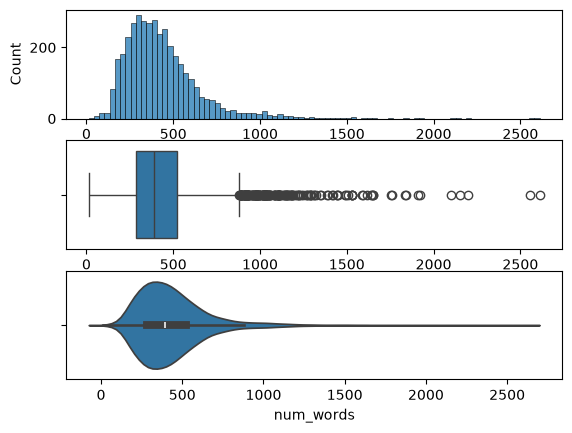

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(3, 1, 1)
sns.histplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 2)
sns.boxplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 3)
sns.violinplot(data=raw_data, x="num_words")

<Axes: xlabel='num_words2'>

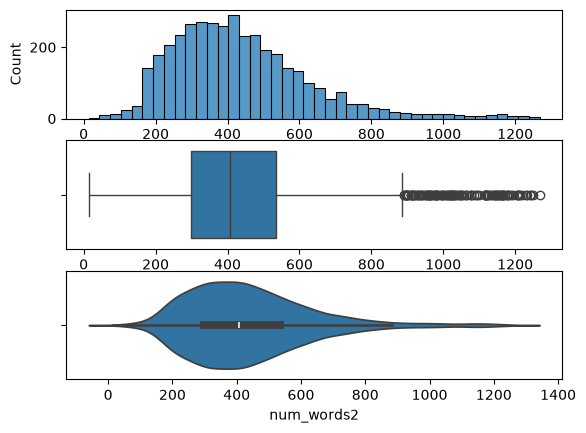

In [ ]:
plt.subplot(3, 1, 1)
sns.histplot(data=raw_data, x="num_words2")
plt.subplot(3, 1, 2)
sns.boxplot(data=raw_data, x="num_words2")
plt.subplot(3, 1, 3)
sns.violinplot(data=raw_data, x="num_words2")

<Axes: xlabel='num_words3'>

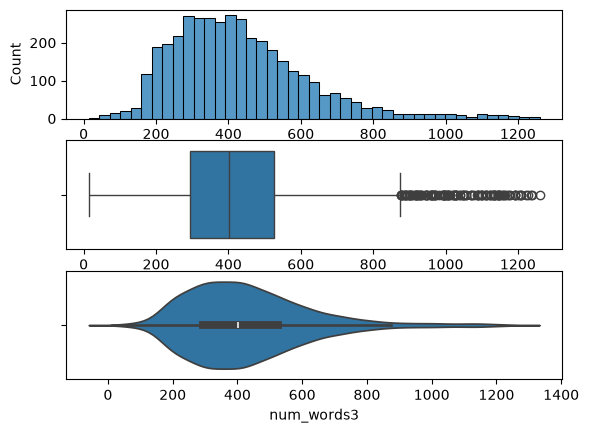

In [17]:
plt.subplot(3, 1, 1)
sns.histplot(data=raw_data, x="num_words3")
plt.subplot(3, 1, 2)
sns.boxplot(data=raw_data, x="num_words3")
plt.subplot(3, 1, 3)
sns.violinplot(data=raw_data, x="num_words3")

<Axes: xlabel='grade', ylabel='Vocabulary'>

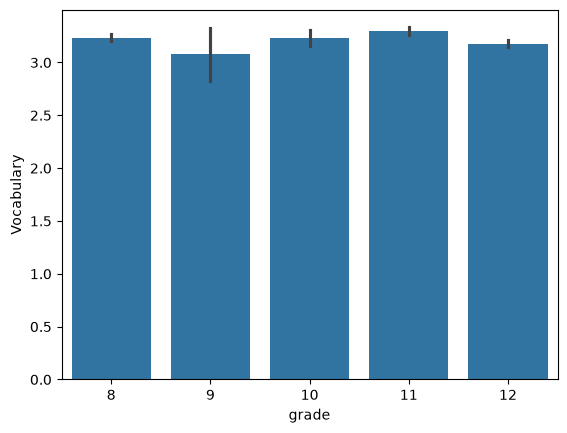

In [24]:
sns.barplot(data=raw_data, x="grade", y='Vocabulary')

<Axes: xlabel='num_words3', ylabel='Vocabulary'>

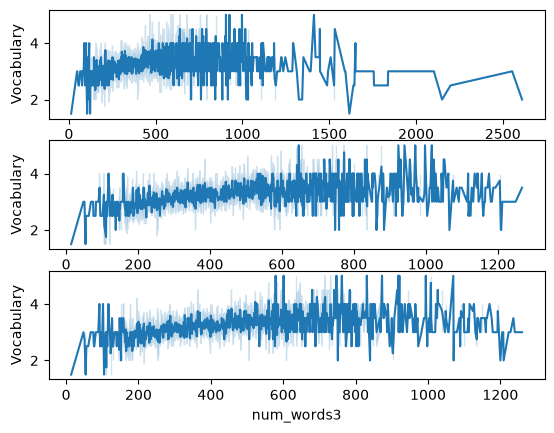

In [23]:
plt.subplot(3, 1, 1)
sns.lineplot(data=raw_data, x="num_words", y='Vocabulary')
plt.subplot(3, 1, 2)
sns.lineplot(data=raw_data, x='num_words2', y='Vocabulary')
plt.subplot(3, 1, 3)
sns.lineplot(data=raw_data, x='num_words3', y='Vocabulary')

# ELLIPSE 코퍼스 — 데이터 정의서

**파일**: `ELLIPSE_Final_github_train.csv`
**규모**: 3,911행 × 26컬럼
**결측치**: 없음 (전 컬럼 0개)
**출처**: [scrosseye/ELLIPSE-Corpus](https://github.com/scrosseye/ELLIPSE-Corpus)

---

## 컬럼 목록

| # | 컬럼명 | 타입 | 고유값 | 범위 / 분포 | 설명 |
|---:|---|---|---:|---|---|
| 1 | `text_id_kaggle` | object | 3,911 | 대부분 12자리 hex | 에세이 고유 식별자 (Kaggle Feedback Prize ID 체계) |
| 2 | `full_text` | object | 3,911 | — | 에세이 원문 전체 |
| 3 | `gender` | object | 2 | Male 2,190 / Female 1,721 | 학습자 성별 |
| 4 | `grade` | int64 | 5 | 8 ~ 12 (평균 10.52) | 학년. 11(1,377) · 12(1,319) · 8(975) · 10(214) · 9(26) |
| 5 | `race_ethnicity` | object | 6 | Hispanic/Latino 2,767 최다 | 인종·민족 |
| 6 | `num_words` | int64 | 850 | 13 ~ 2,611 (평균 436.78) | 단어 수 — 정의 불명, 타 지표와 상관 0.78 |
| 7 | `num_words2` | int64 | 824 | 14 ~ 1,268 (평균 436.40) | 공백 기준 토큰 수 — `Token`과 값 완전 동일 |
| 8 | `num_words3` | int64 | 816 | 14 ~ 1,260 (평균 430.49) | `num_words2`보다 평균 5.9 적음 (구두점·숫자 제외 추정) |
| 9 | `num_sent` | int64 | 66 | 1 ~ 99 (평균 18.27) | 문장 수 |
| 10 | `num_para` | int64 | 32 | 1 ~ 52 (평균 5.54) | 문단 수 |
| 11 | `num_word_div_para` | float64 | 1,895 | 3.50 ~ 1,192.00 (평균 94.46) | 평균 문단 길이 (문단별 단어 수의 산술평균) |
| 12 | `MTLD` | float64 | 3,890 | 12.25 ~ 103.14 (평균 45.98) | 어휘 다양성 지표. 글 길이에 덜 민감 |
| 13 | `TTR` | float64 | 3,479 | 14.01 ~ 92.86 (평균 36.94) | Type-Token Ratio = `Type / Token × 100` |
| 14 | `Type` | int64 | 280 | 13 ~ 387 (평균 150.77) | 고유 단어 종류 수 |
| 15 | `Token` | int64 | 824 | 14 ~ 1,268 (평균 436.40) | 총 토큰 수 |
| 16 | `task` | object | **1** | 전부 `Independent` | 과제 유형 (자료 없이 쓰는 독립 작문) |
| 17 | `SES` | object | 2 | 경제적 취약 2,709 / 비취약 1,202 | 사회경제적 지위 |
| 18 | `prompt` | object | 44 | Distance learning 297 최다 | 에세이 주제 |
| 19 | `Overall` | float64 | 9 | 1.0 ~ 5.0 (평균 3.11) | 종합 점수 |
| 20 | `Cohesion` | float64 | 9 | 1.0 ~ 5.0 (평균 3.13) | 응집성 |
| 21 | `Syntax` | float64 | 9 | 1.0 ~ 5.0 (평균 3.03) | 구문 |
| 22 | `Vocabulary` | float64 | 9 | 1.0 ~ 5.0 (평균 3.24) | 어휘 |
| 23 | `Phraseology` | float64 | 9 | 1.0 ~ 5.0 (평균 3.12) | 연어·표현 |
| 24 | `Grammar` | float64 | 9 | 1.0 ~ 5.0 (평균 3.03) | 문법 |
| 25 | `Conventions` | float64 | 9 | 1.0 ~ 5.0 (평균 3.08) | 표기 규범 (철자·구두점 등) |
| 26 | `set` | object | **1** | 전부 `train` | 데이터 분할 표시 |

---

## 컬럼 간 확인된 관계

| 관계 | 검증 결과 |
|---|---|
| `num_words2` = `Token` | 3,911행 전부 일치 |
| `TTR` = `Type` / `Token` × 100 | 전부 일치 (오차 1e-4 이내) |
| `num_word_div_para` = 문단별 단어 수의 평균 | 전부 일치 (오차 1e-3 이내) |
| `num_words3` ≈ `num_words2` | 상관 0.9993, 평균 차이 5.9 |
| `Overall` = 나머지 6개 점수의 평균 | **불일치** — 별도로 매겨진 독립 점수 |

## 점수 컬럼 공통 사항

7개 점수(`Overall`, `Cohesion`, `Syntax`, `Vocabulary`, `Phraseology`, `Grammar`, `Conventions`) 모두 동일한 척도를 사용한다.

- 범위: 1.0 ~ 5.0
- 간격: 0.5 단위 → 고유값 9개 (1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0)
- 평균 3.03 ~ 3.24, 표준편차 0.58 ~ 0.70 → 중앙에 집중된 분포

`Overall`과 나머지 6개의 상관계수는 0.774 ~ 0.812이다.

## 데이터 전처리 1 (가비지 컬럼 삭제)
### 삭제할 컬럼:
#### 가비지 컬럼 (중복 또는 단순 인덱스)
- text_id_kaggle : 단순 데이터 구분용 식별자 (캐글에서 붙임.)
- set : 데이터가 학습용인지, 검증용인지 분류 (애초에 학습용 데이터만 모은 csv이므로 컬럼 삭제)
- num_words2 : Token과 중복되는 컬럼(완벽히 일치)
-----------
#### 인구통계 컬럼 (윤리적 문제)
-> 독립변수 제외, EDA에서는 다루기
- gender : 성별
- race_ethnicity : 인종
- SES : 사회경제적 지위
-----------
#### 데이터 누수 컬럼 (모델이 알면 안되는 값)
- Overall : 총점
- Cohesion : 응집성
- Syntax : 구문
- Phraseology : 연어, 표현
- Grammar : 문법
- Conventions : 표기 규범(철자, 구두점 등)